In [1]:
# 1. Ignore Warnings

import warnings
warnings.filterwarnings("ignore")

In [2]:
# 2. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 3. Display Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
# 4. Load Dataset

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [5]:
# 5.View Dataset

train_df.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [6]:
# 6. Dataset Shape

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (140700, 20)
Test Shape : (93800, 19)


In [7]:
# 7. Dataset Information

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [8]:
# 8. Missing Value Analysis

# 8.1 Missing Values Count

train_df.isnull().sum()

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [9]:
# 8.2 Missing Value Percentage

missing_percentage = (
    train_df.isnull().sum() / len(train_df)
) * 100

missing_percentage.sort_values(
    ascending=False
)

Study Satisfaction                       80.172708
Academic Pressure                        80.172708
CGPA                                     80.171997
Profession                               26.034115
Work Pressure                            19.842217
Job Satisfaction                         19.836532
Financial Stress                          0.002843
Dietary Habits                            0.002843
Degree                                    0.001421
Gender                                    0.000000
Name                                      0.000000
id                                        0.000000
Age                                       0.000000
City                                      0.000000
Working Professional or Student           0.000000
Sleep Duration                            0.000000
Have you ever had suicidal thoughts ?     0.000000
Work/Study Hours                          0.000000
Family History of Mental Illness          0.000000
Depression                     

### 8.3 Missing Value Observation
### Observation

- Academic Pressure, Study Satisfaction, and CGPA contain high missing values because these features are mainly related to students.

- Work Pressure and Job Satisfaction are mostly applicable to working professionals.

- Remaining columns contain very few missing values.

In [10]:
# 9. Duplicate Value Analysis

train_df.duplicated().sum()

np.int64(0)

In [11]:
# 10. Column Names

train_df.columns

Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [12]:
# 11. Statistical Summary

train_df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [13]:
# 12. Numerical and Categorical Columns

# 12.1 Numerical Columns

numerical_columns = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove unnecessary columns
numerical_columns.remove("Depression")
numerical_columns.remove("id")

numerical_columns

['Age',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Work/Study Hours',
 'Financial Stress']

In [14]:
# 12.2 Categorical Columns

categorical_columns = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_columns

['Name',
 'Gender',
 'City',
 'Working Professional or Student',
 'Profession',
 'Sleep Duration',
 'Dietary Habits',
 'Degree',
 'Have you ever had suicidal thoughts ?',
 'Family History of Mental Illness']

In [15]:
# 13. Target Variable Analysis

# 13.1 Target Distribution Count

train_df["Depression"].value_counts()

Depression
0    115133
1     25567
Name: count, dtype: int64

In [16]:
# 13.2 Target Distribution Percentage

(
    train_df["Depression"]
    .value_counts(normalize=True) * 100
)

Depression
0    81.828714
1    18.171286
Name: proportion, dtype: float64

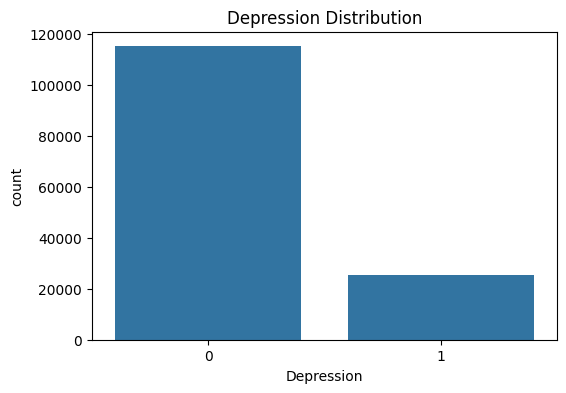

In [17]:
# 13.3 Target Visualization

plt.figure(figsize=(6,4))

sns.countplot(
    x="Depression",
    data=train_df
)

plt.title("Depression Distribution")

plt.show()

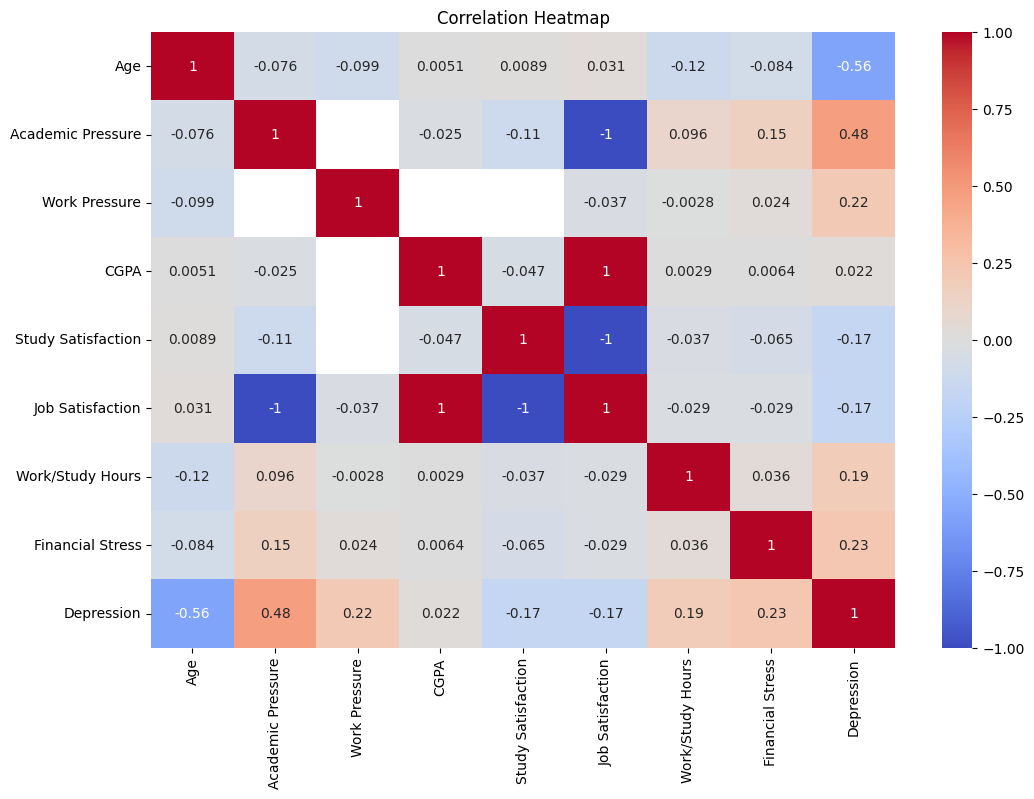

In [18]:
# 14. Correlation Analysis

# 14.1 Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    train_df[numerical_columns + ["Depression"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

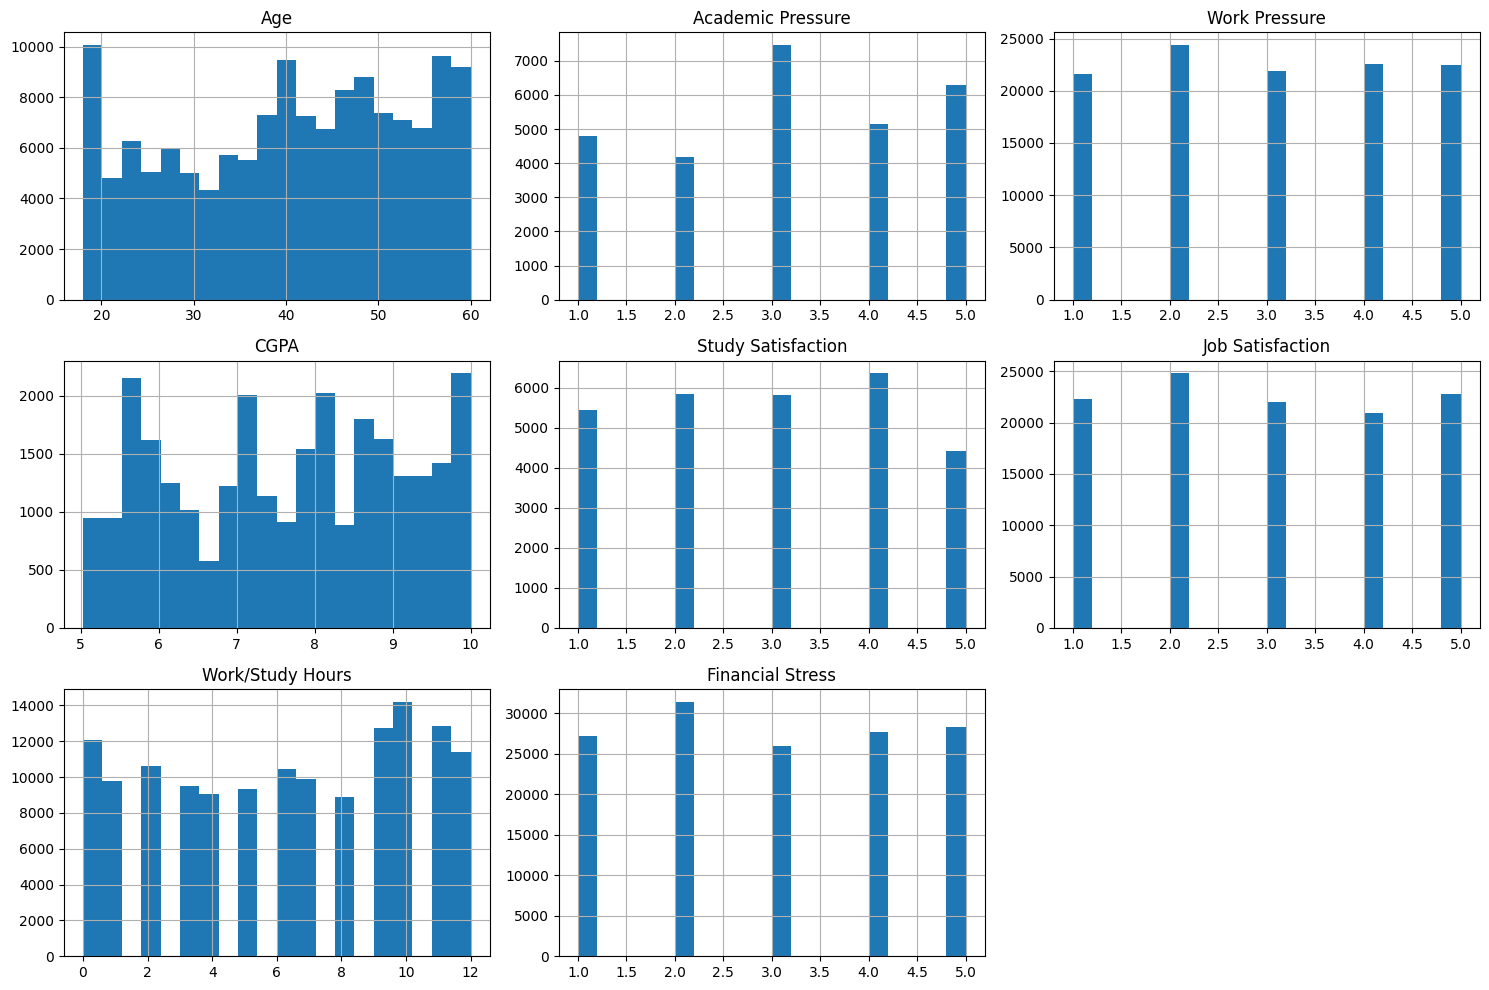

In [19]:
# 15. Univariate Analysis

# 15.1 Numerical Feature Distribution

train_df[numerical_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

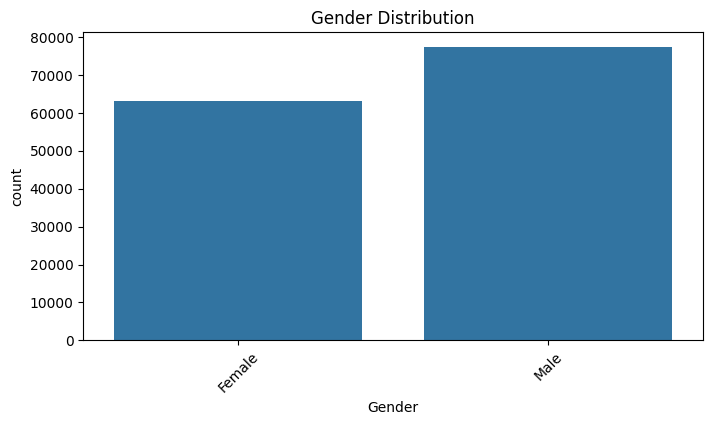

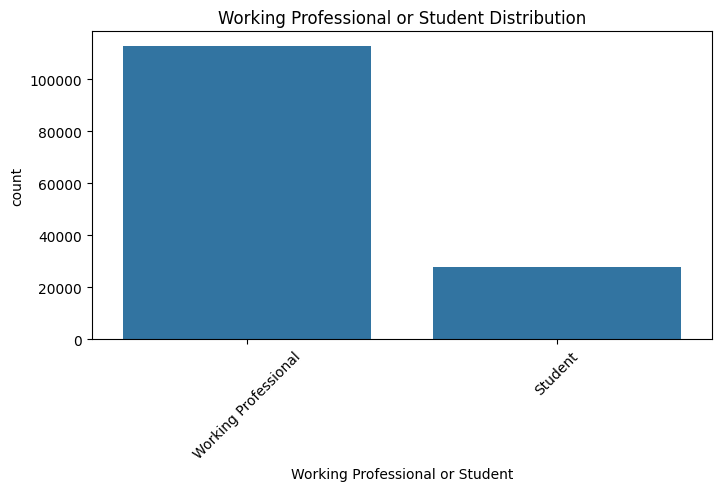

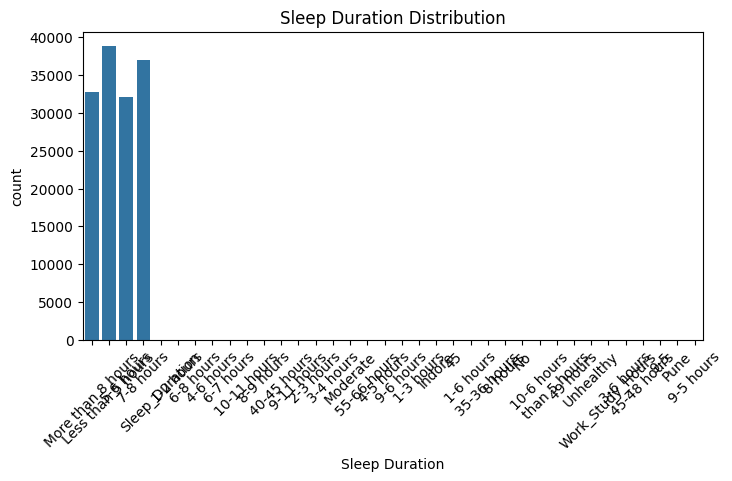

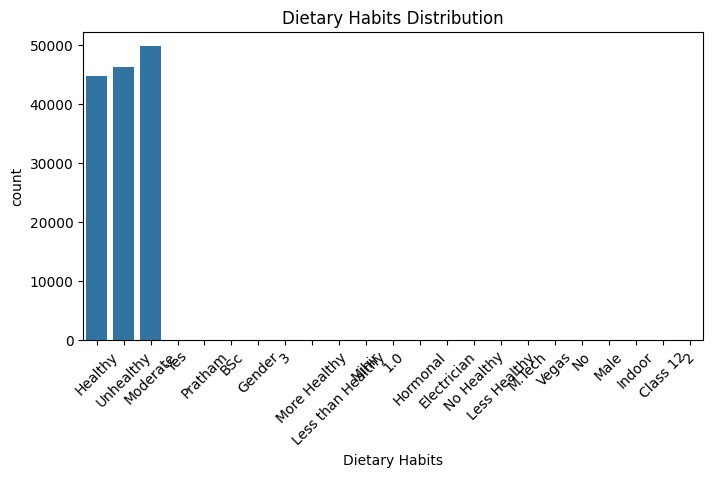

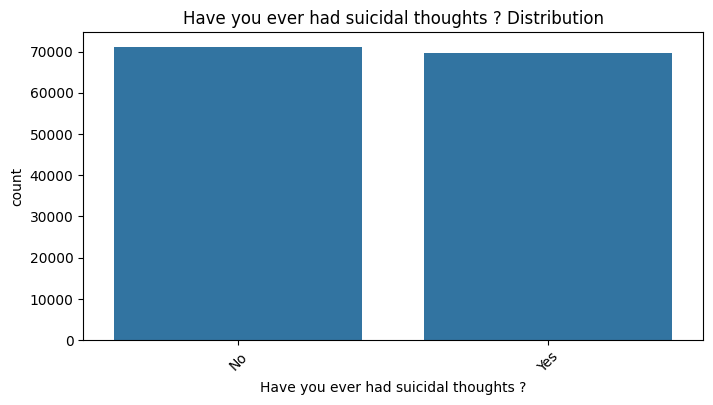

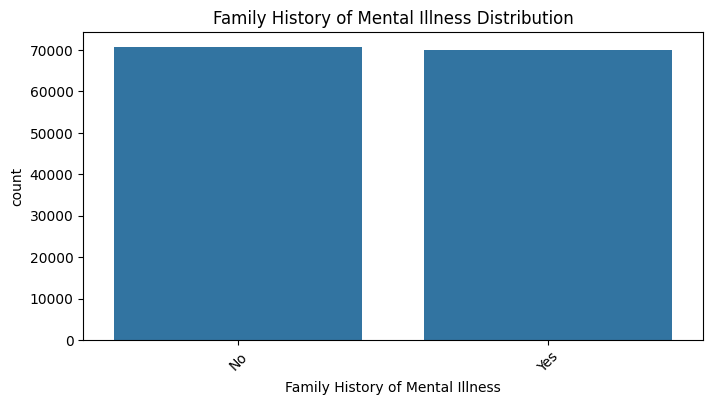

In [20]:
# 15.2 Categorical Feature Distribution

important_cat_cols = [
    "Gender",
    "Working Professional or Student",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]

for column in important_cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        x=column,
        data=train_df
    )

    plt.title(f"{column} Distribution")

    plt.xticks(rotation=45)

    plt.show()

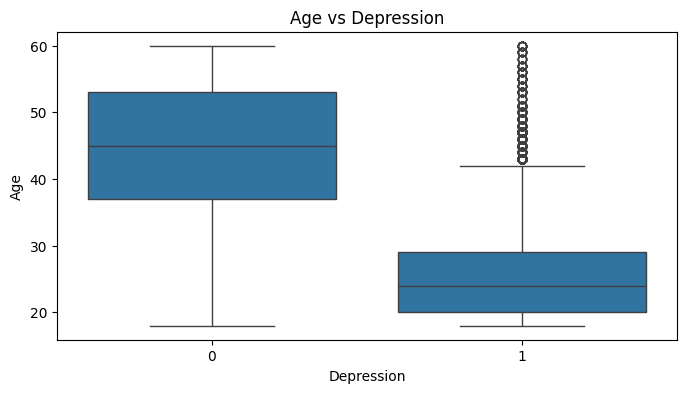

In [21]:
# 16. Bivariate Analysis

# 16.1 Age vs Depression

plt.figure(figsize=(8,4))

sns.boxplot(
    x="Depression",
    y="Age",
    data=train_df
)

plt.title("Age vs Depression")

plt.show()

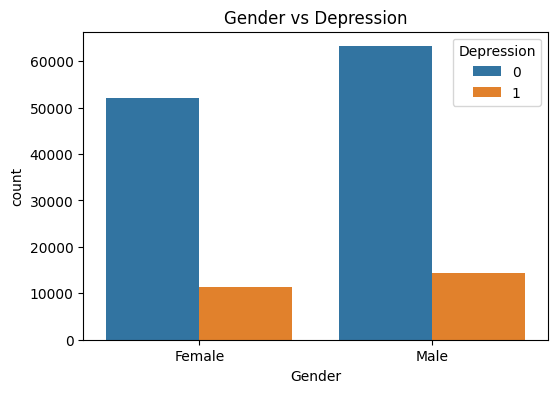

In [22]:
# 16.2 Gender vs Depression

plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Depression",
    data=train_df
)

plt.title("Gender vs Depression")

plt.show()

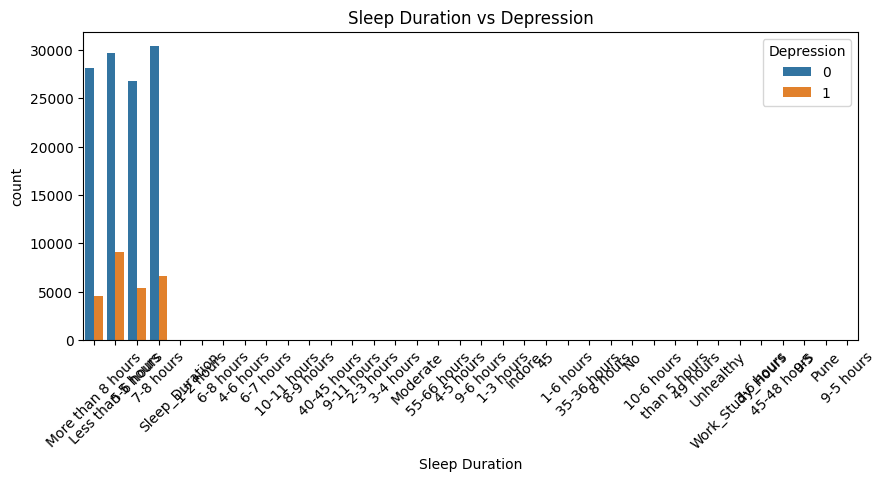

In [23]:
# 16.3 Sleep Duration vs Depression

plt.figure(figsize=(10,4))

sns.countplot(
    x="Sleep Duration",
    hue="Depression",
    data=train_df
)

plt.title("Sleep Duration vs Depression")

plt.xticks(rotation=45)

plt.show()

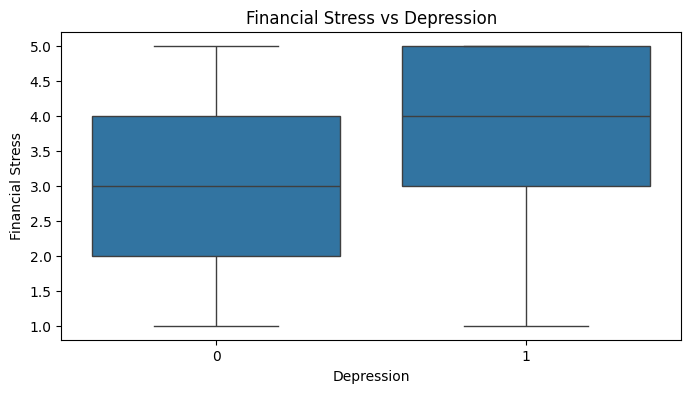

In [24]:
# 16.4 Financial Stress vs Depression

plt.figure(figsize=(8,4))

sns.boxplot(
    x="Depression",
    y="Financial Stress",
    data=train_df
)

plt.title("Financial Stress vs Depression")

plt.show()

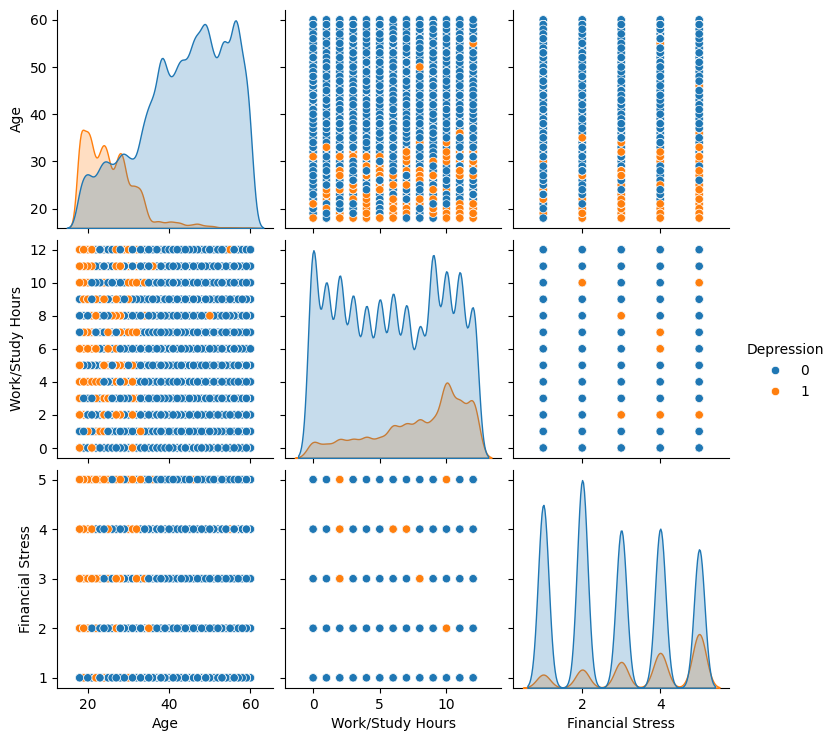

In [25]:
# 17. Multivariate Analysis

# 17.1 Pairplot
sns.pairplot(
    train_df[
        [
            "Age",
            "Work/Study Hours",
            "Financial Stress",
            "Depression"
        ]
    ],
    hue="Depression"
)

plt.show()

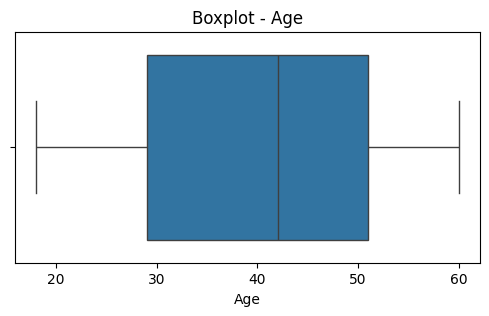

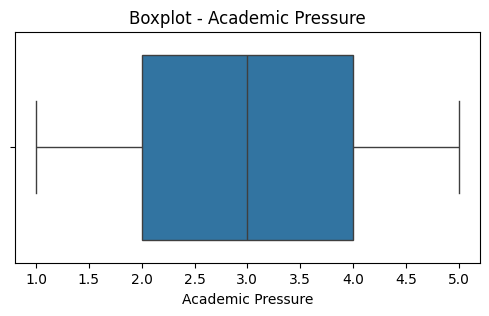

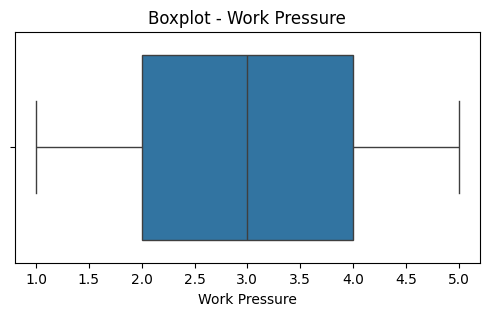

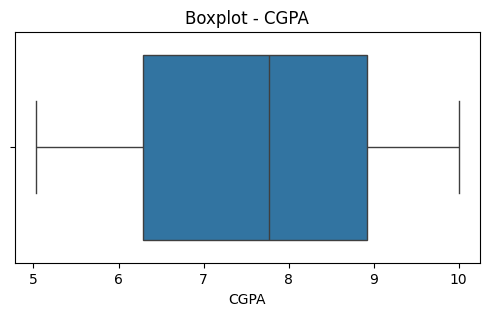

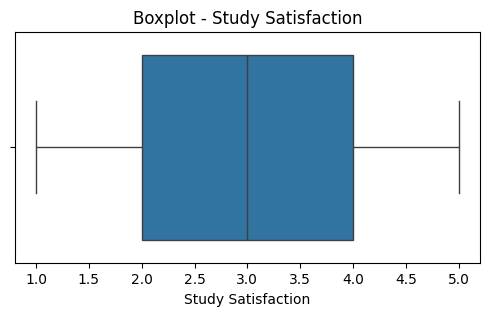

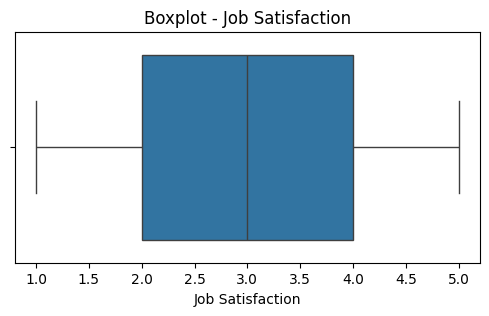

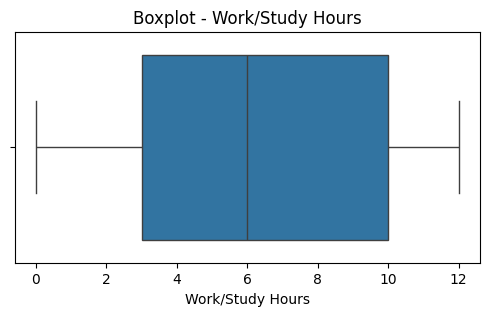

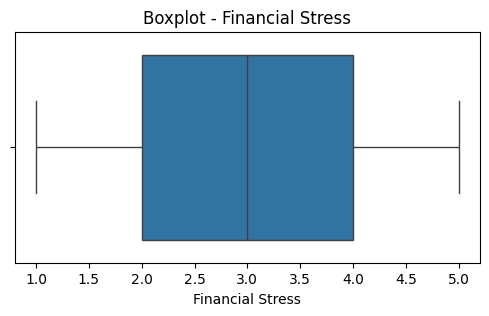

In [26]:
# 18. Outlier Analysis

for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=train_df[column]
    )

    plt.title(f"Boxplot - {column}")

    plt.show()

19. Final EDA Observations
Markdown Cell
## Final Observations

- The dataset contains class imbalance, with most individuals not having depression.

- Financial stress and sleep duration appear to influence depression.

- Student-related features contain high missing values for working professionals.

- Some numerical features contain outliers.

- Features such as suicidal thoughts and family history of mental illness may strongly influence depression prediction.

In [27]:
# 20. Final Message

print("EDA Completed Successfully")

EDA Completed Successfully
